In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df1 = pd.read_csv("/home/mengelsl/MA-bench-framework/eigen/outputs/perf_20251219_184301/perf_results.csv")
df2 = pd.read_csv("/home/mengelsl/MA-bench-framework/eigen/outputs/perf_20251219_185410/perf_results.csv")

df1['run_id'] = 'Custom_OMP'
df2['run_id'] = 'Default_OMP'

df_all = pd.concat([df1, df2])


In [2]:
def calculate_metrics(group):
    t1 = group.loc[group['cores'] == 1, 'real_time_s'].mean()
    group['speedup'] = t1 / group['real_time_s']
    group['efficiency'] = group['speedup'] / group['cores']
    return group

df_final = df_all.groupby('run_id', group_keys=False).apply(calculate_metrics)

df_final.head()

/tmp/ipykernel_3829848/1400749290.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final = df_all.groupby('run_id', group_keys=False).apply(calculate_metrics)


,cores,run,algorithm,matrix,real_time_s,user_time_s,sys_time_s,instructions,cycles,cache_misses,run_id,speedup,efficiency
0,1,1,lanczos,matrices/binary/dawson5.dat,160060975,136528000,8925000,1858553112,538011240,2495799,Custom_OMP,0.941952,0.941952
1,1,2,lanczos,matrices/binary/dawson5.dat,146044002,134122000,10826000,1858576076,536530955,2544744,Custom_OMP,1.032358,1.032358
2,1,3,lanczos,matrices/binary/dawson5.dat,150768354,139013000,10923000,1858685802,554662885,2562782,Custom_OMP,1.000009,1.000009
3,1,4,lanczos,matrices/binary/dawson5.dat,147722587,136873000,9995000,1860799650,543261999,2578728,Custom_OMP,1.020627,1.020627
4,1,5,lanczos,matrices/binary/dawson5.dat,149252631,139421000,8947000,1858611618,549104855,2534563,Custom_OMP,1.010165,1.010165


<Axes: xlabel='cores', ylabel='speedup'>

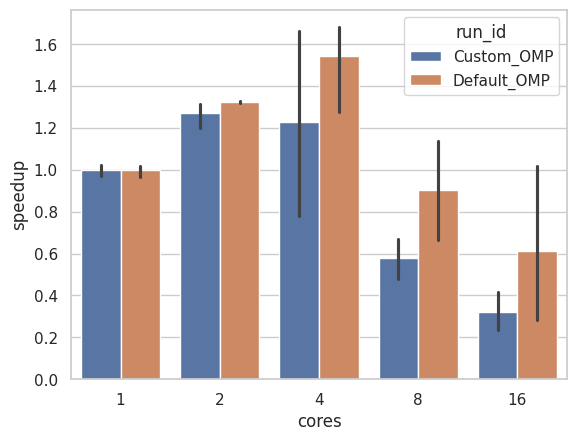

In [3]:
sns.barplot(data=df_final, x='cores', y='speedup', hue='run_id')

<Axes: xlabel='cores', ylabel='real_time_s'>

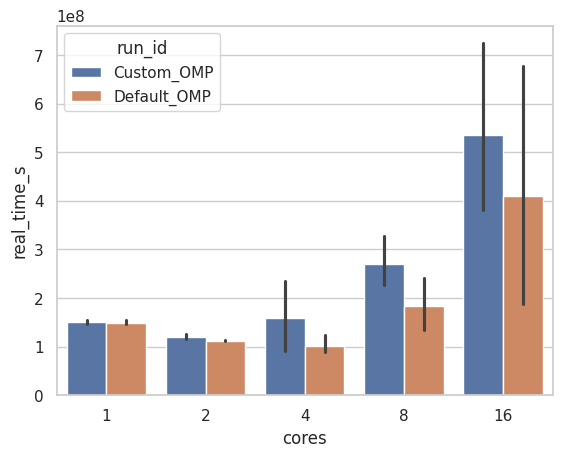

In [4]:

sns.barplot(data=df_final, x='cores', y='real_time_s', hue='run_id')